In [111]:
%reload_ext autoreload
%autoreload 2

import importlib

import numpy as np
import matplotlib.pyplot as plt
import state_to_edgepoints as state_to_edgepoints_module

state_to_edgepoints_module = importlib.reload(state_to_edgepoints_module)
state_to_edgepoints = state_to_edgepoints_module.state_to_edgepoints

import sys

# go out of folder to import the CR alg
sys.path.append("..")

from filters import ChristianRobinson 



from datetime import datetime
from dataclasses import dataclass
import pytz
from enum import Enum

from utils import circle_points, camera_view, noise
from classes import Camera, Body, PlanetImage, Pose

from filters import SatEKF


from InterfaceWrapperFuncs import Set_camera, gen_traj, plot_traj, get_images,run_step, get_tpc, plot_est_dist_xyz, plot_est_dist_xyz_errors, plot_trajs

In [112]:
f, mu, n_pixels = Set_camera() #Sagitta camera parameters


# One-time calculation
camera = Camera(f, mu, n_pixels)
camera.calc_specs()
moon_radius = 1737.4 # km
moon_mu = 4902.800066 # km^3/s^2

body = Body(a=moon_radius, b=moon_radius, c=moon_radius)
#print(camera)
print(body)


w, h = 1280, 720
K = np.array(
    [
        [1120.0, 0.0, w / 2.0],
        [0.0, 1120.0, h / 2.0],
        [0.0, 0.0, 1.0],
    ],
    dtype=np.float64,
)

k_inv = np.linalg.inv(K)

camera_spec_ellie = {
    "K": K,
    "width": w,
    "height": h,
}

camera_spec_ellie2 = {
    "K": np.linalg.inv(camera.K_inv),
    "width": camera.resolution[0],
    "height": camera.resolution[1],
}

cr_alg = ChristianRobinson(k_inv, body.a, body.b, body.c)


Worldview:
 - Ellipsoid semi-axes a,b,c = [1737.4, 1737.4, 1737.4] km



Orbital period (T): 45980.8058633618s


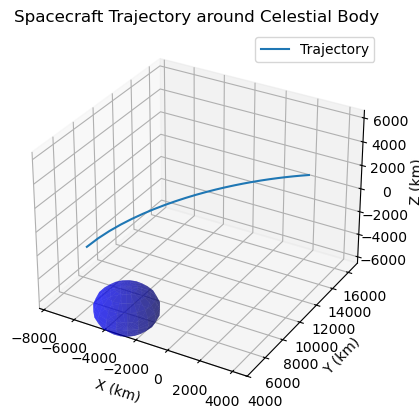

24
0


In [124]:
pos = np.array([-5000, 4000, 100])
r = np.linalg.norm(pos)
v = np.sqrt( moon_mu / r) + 0.2 # km/s, slightly
State0 = [pos[0], pos[1], pos[2], 0, v, 0] 



dt = 1000
op, body_struct = gen_traj(Starting_state=State0, dt=dt)
plot_traj(op.states, body_struct)

print(len(op.states))
print(op.ts[0])


In [125]:
# for 10 points along traj gen images and test CR alg
cam_offset = np.array([0, 0, 0]) # no offset for now
images, edges, outs, states, times = get_images(op.states, op.ts, body_struct, cam_offset, camera_spec_ellie, 10)


State at t=0.0s: [-5.000e+03  4.000e+03  1.000e+02  0.000e+00  1.075e+00  0.000e+00]
State at t=1000.0s: [-4.958e+03  5.038e+03  9.916e+01  8.034e-02  1.002e+00 -1.607e-03]
State at t=2000.0s: [-4.846e+03  6.007e+03  9.692e+01  1.401e-01  9.355e-01 -2.802e-03]
State at t=3000.0s: [-4.682e+03  6.911e+03  9.365e+01  1.853e-01  8.743e-01 -3.707e-03]
State at t=4000.0s: [-4.479e+03  7.757e+03  8.958e+01  2.201e-01  8.188e-01 -4.402e-03]
State at t=5000.0s: [-4.245e+03  8.551e+03  8.490e+01  2.472e-01  7.683e-01 -4.944e-03]
State at t=6000.0s: [-3.986e+03  9.295e+03  7.973e+01  2.685e-01  7.222e-01 -5.370e-03]
State at t=7000.0s: [-3.709e+03  9.996e+03  7.418e+01  2.854e-01  6.800e-01 -5.707e-03]
State at t=8000.0s: [-3.417e+03  1.066e+04  6.834e+01  2.988e-01  6.412e-01 -5.976e-03]
State at t=9000.0s: [-3.113e+03  1.128e+04  6.225e+01  3.095e-01  6.053e-01 -6.190e-03]


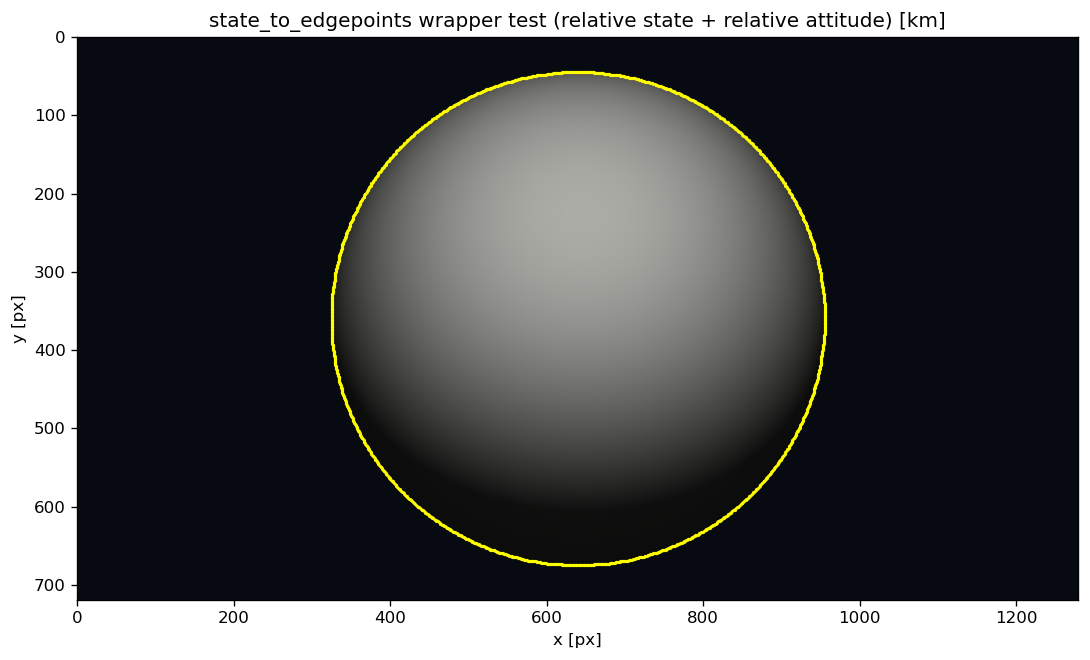

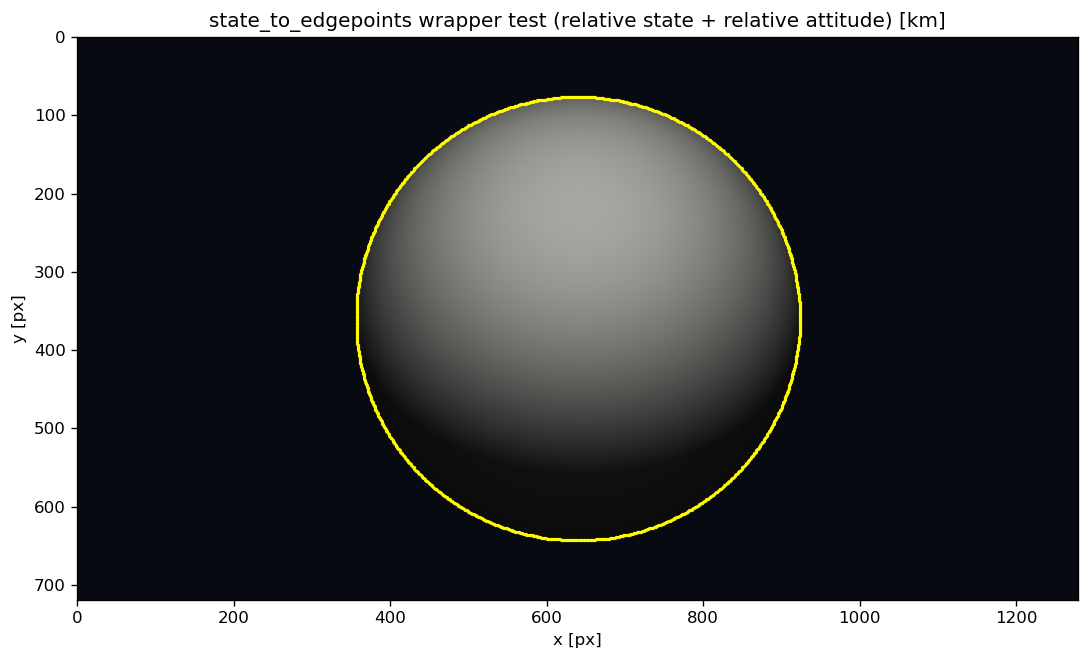

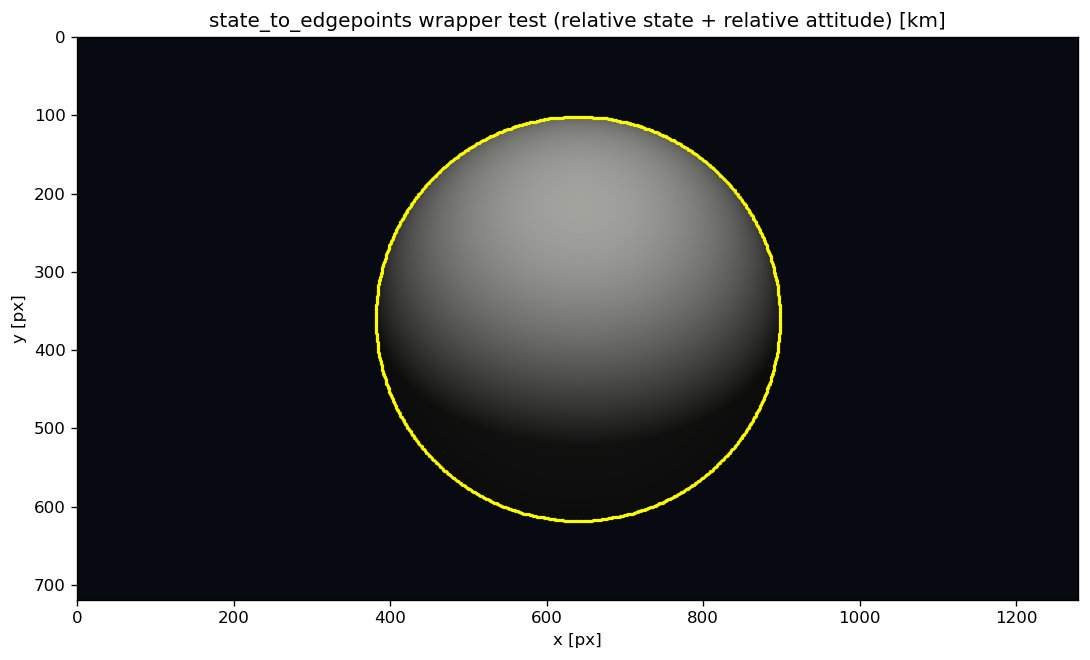

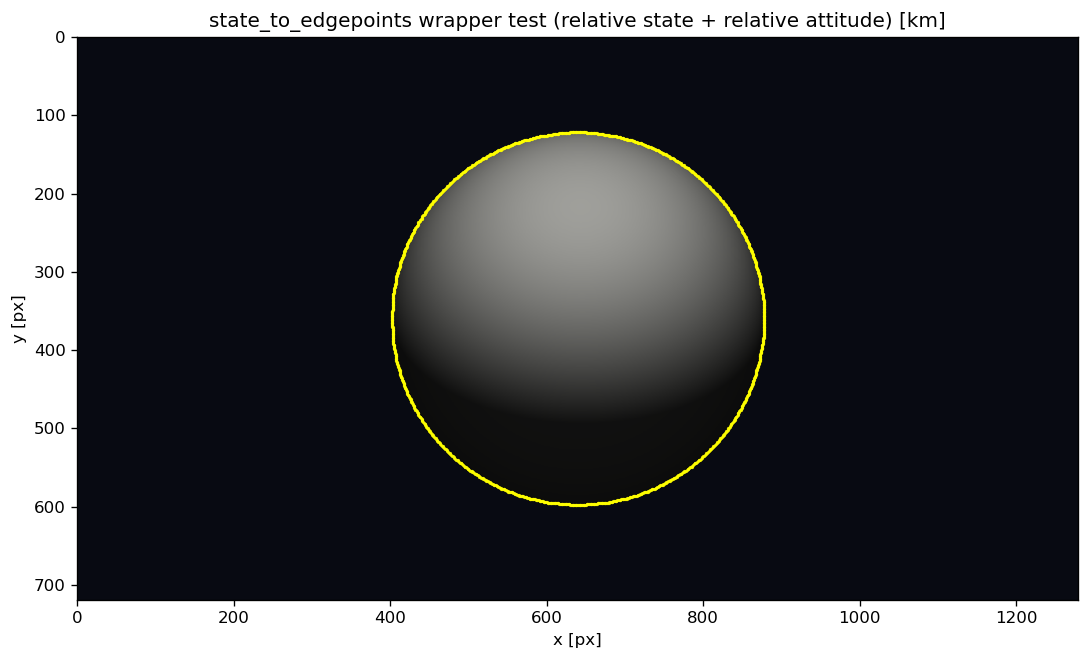

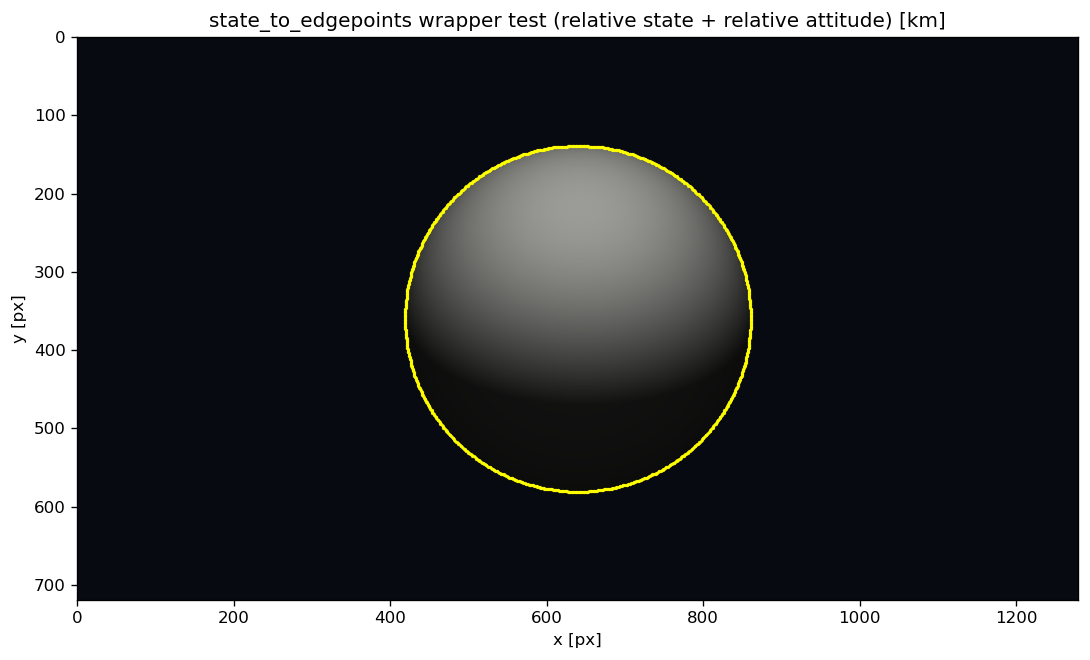

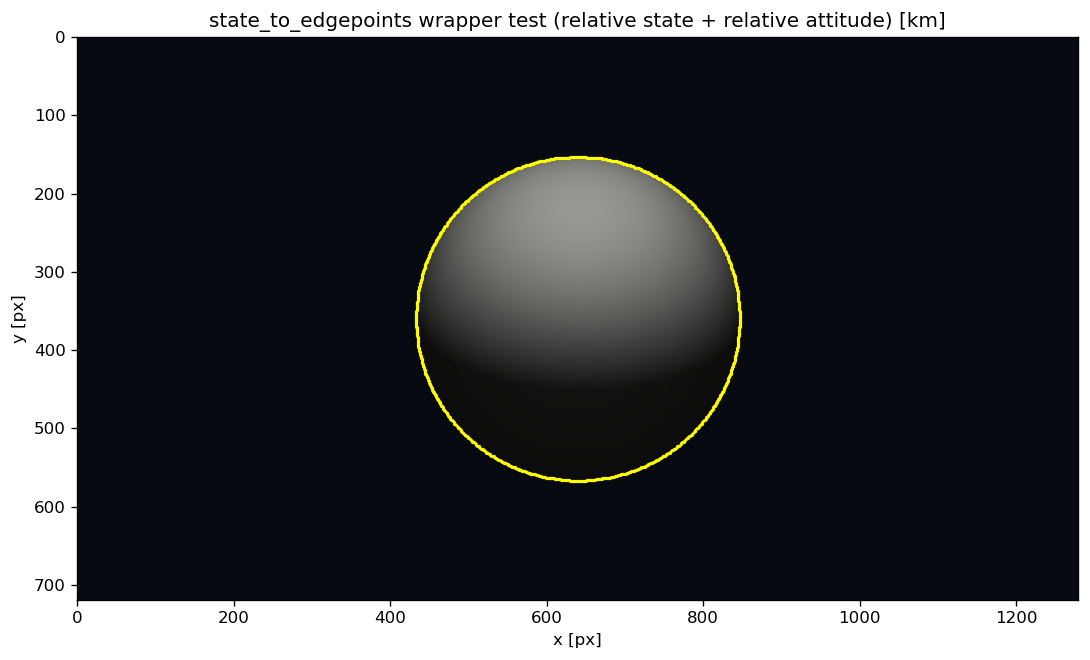

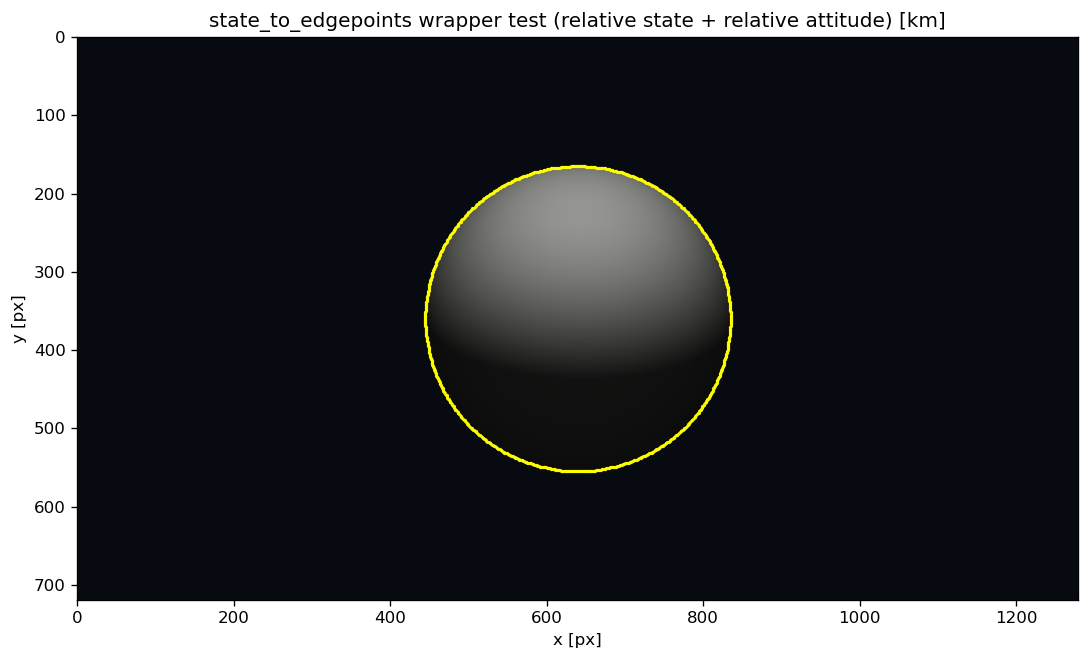

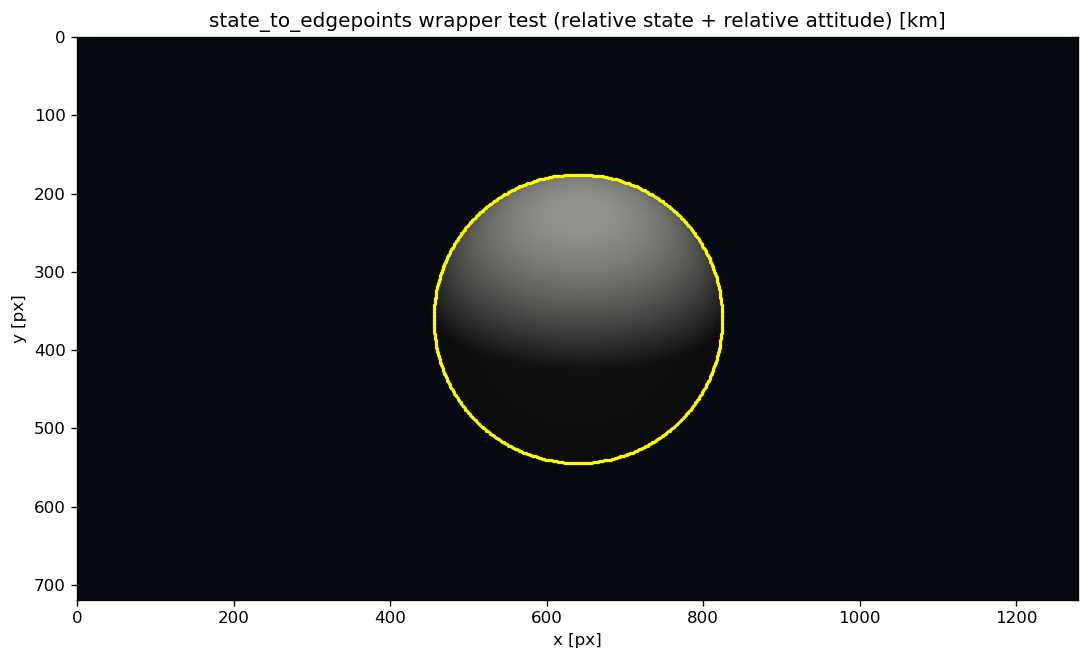

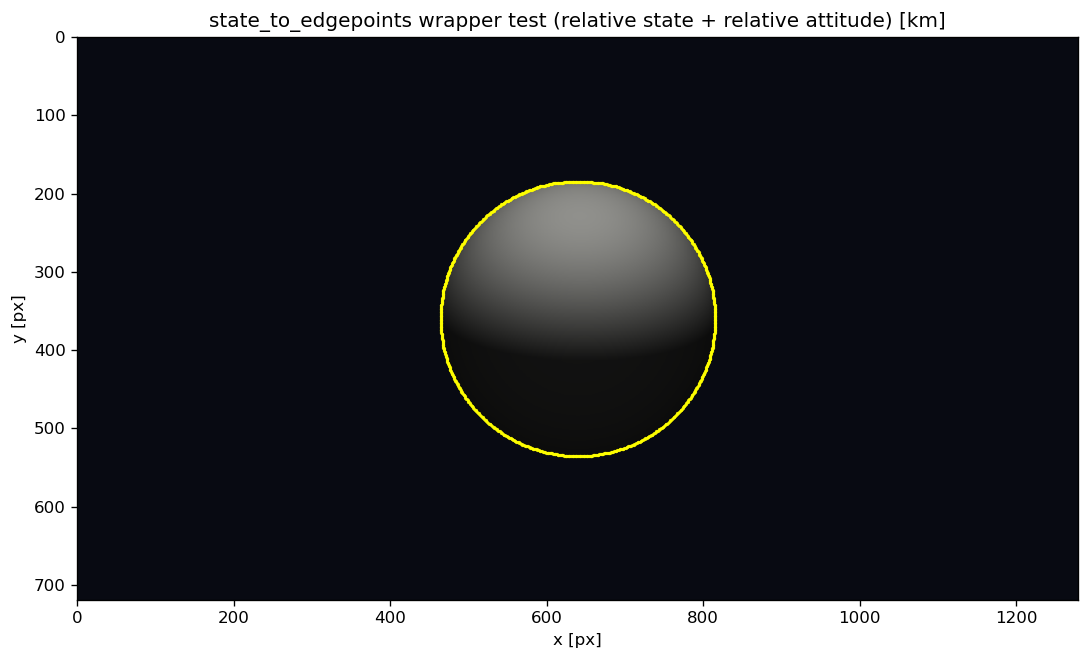

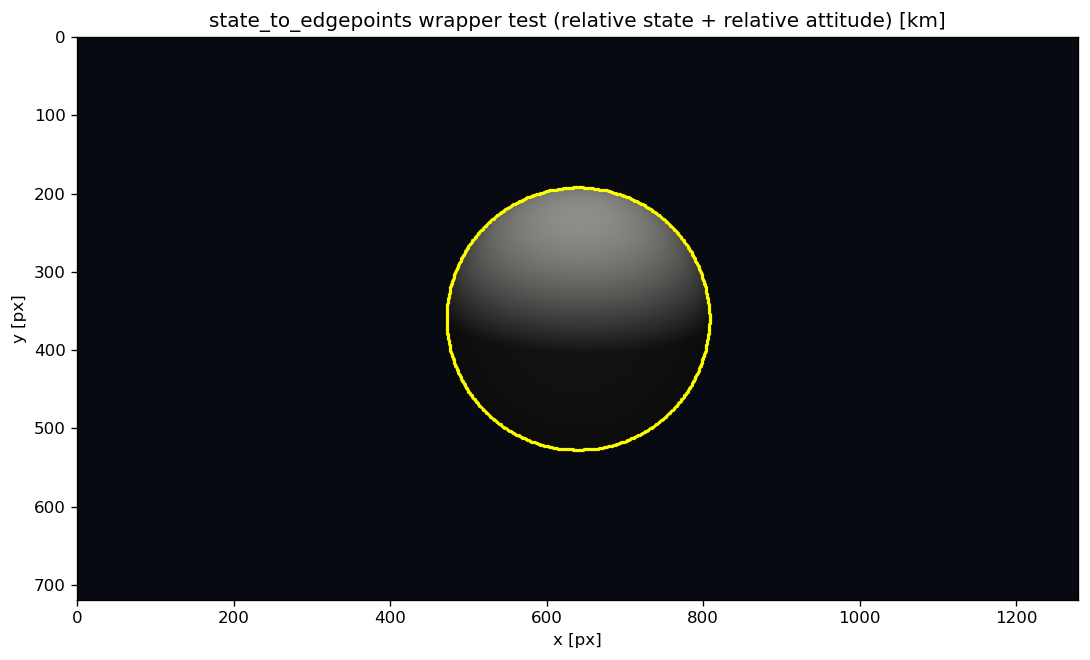

In [126]:

i = 0
for out in outs:
    i += 1
    if i % 1 == 0:
        w, h = camera_spec_ellie["width"], camera_spec_ellie["height"]
        state_to_edgepoints_module.plot_edge_points(
            out,
            w,
            h,
            x_limits=None,
            y_limits=None,
        )

In [127]:

# Running Christian-Robinson algorithm on all images
# Note: Camera offset is now handled in get_images() via attitude_offset_from_center_pointing

estimates = []
for i in range(len(outs)):
    print(f"Running CR alg on image {i+1}/{len(outs)}")
    out = outs[i]
    state = states[i]
    edge = edges[i]
    
    # Compute planet-to-camera rotation matrix from render output
    tpc = get_tpc(out)
    
    # Prepare edge points as homogeneous coordinates [x, y, 1]
    edge_homogeneous = np.hstack((edge, np.ones((edge.shape[0], 1))))

    # Run Christian-Robinson: estimates camera->planet vector in camera frame
    rc_est, rp_est = run_step(edge_homogeneous, state[0:3], tpc, print_stats=True, cr_alg=cr_alg)
    estimates.append(-rp_est)

Running CR alg on image 1/10
Calc Position:
 - (C->P in camera frame): [   0.     -0.   6413.39] (6413.39 km)
 - (C->P in planet frame): [ 5007.4  -4005.92  -100.15] (6413.39 km)
Actual position:
 - (C->P in camera frame): [   0.     -0.   6403.91] (6403.91 km)
 - (C->P in planet frame): [ 5000. -4000.  -100.] (6403.91 km)
Est Error - Actual:
 - (Camera frame): [ 0.   -0.    9.48] (9.48 km)
 - (Planet frame): [ 7.4  -5.92 -0.15] (9.48 km)
Distance error: 9.48 km (0.148060%)
Angular error: 0.0000 degrees
Running CR alg on image 2/10
Calc Position:
 - (C->P in camera frame): [  -0.      0.   7081.89] (7081.89 km)
 - (C->P in planet frame): [ 4966.66 -5047.35   -99.33] (7081.89 km)
Actual position:
 - (C->P in camera frame): [  -0.     -0.   7069.25] (7069.25 km)
 - (C->P in planet frame): [ 4957.79 -5038.34   -99.16] (7069.25 km)
Est Error - Actual:
 - (Camera frame): [-0.    0.   12.64] (12.64 km)
 - (Planet frame): [ 8.87 -9.01 -0.18] (12.64 km)
Distance error: 12.64 km (0.178826%)
Ang

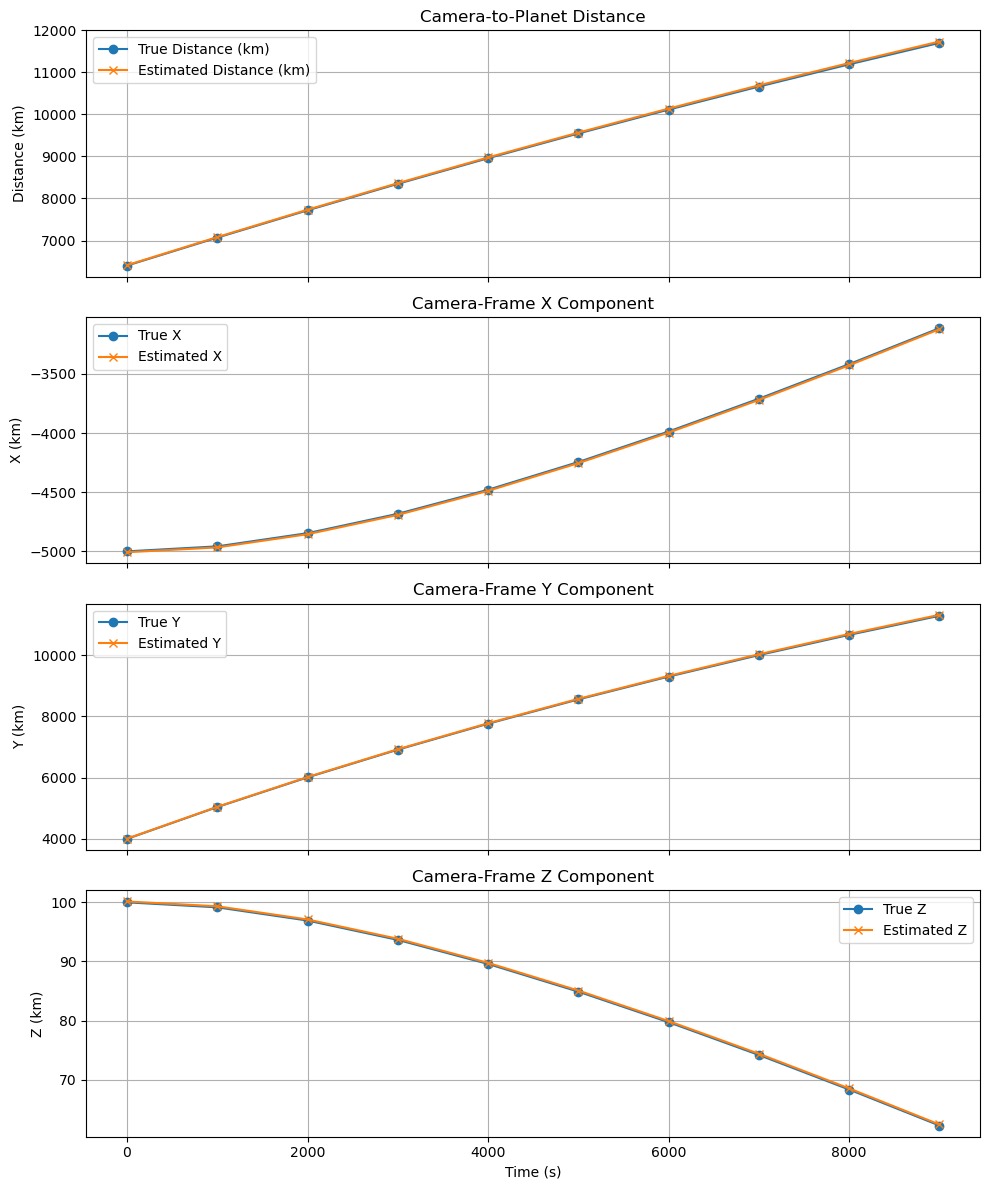

In [128]:
# compare true/estimated camera-frame vectors and distances with optional axis limits
states = np.array(states)
pos = states[:, 0:3]
estimates = np.array(estimates)
times = np.array(times)

#print(np.shape(pos))
#print(estimates[:, 1])
#print("times:", times)



plot_est_dist_xyz(
    times,
    pos,
    estimates,
    
)

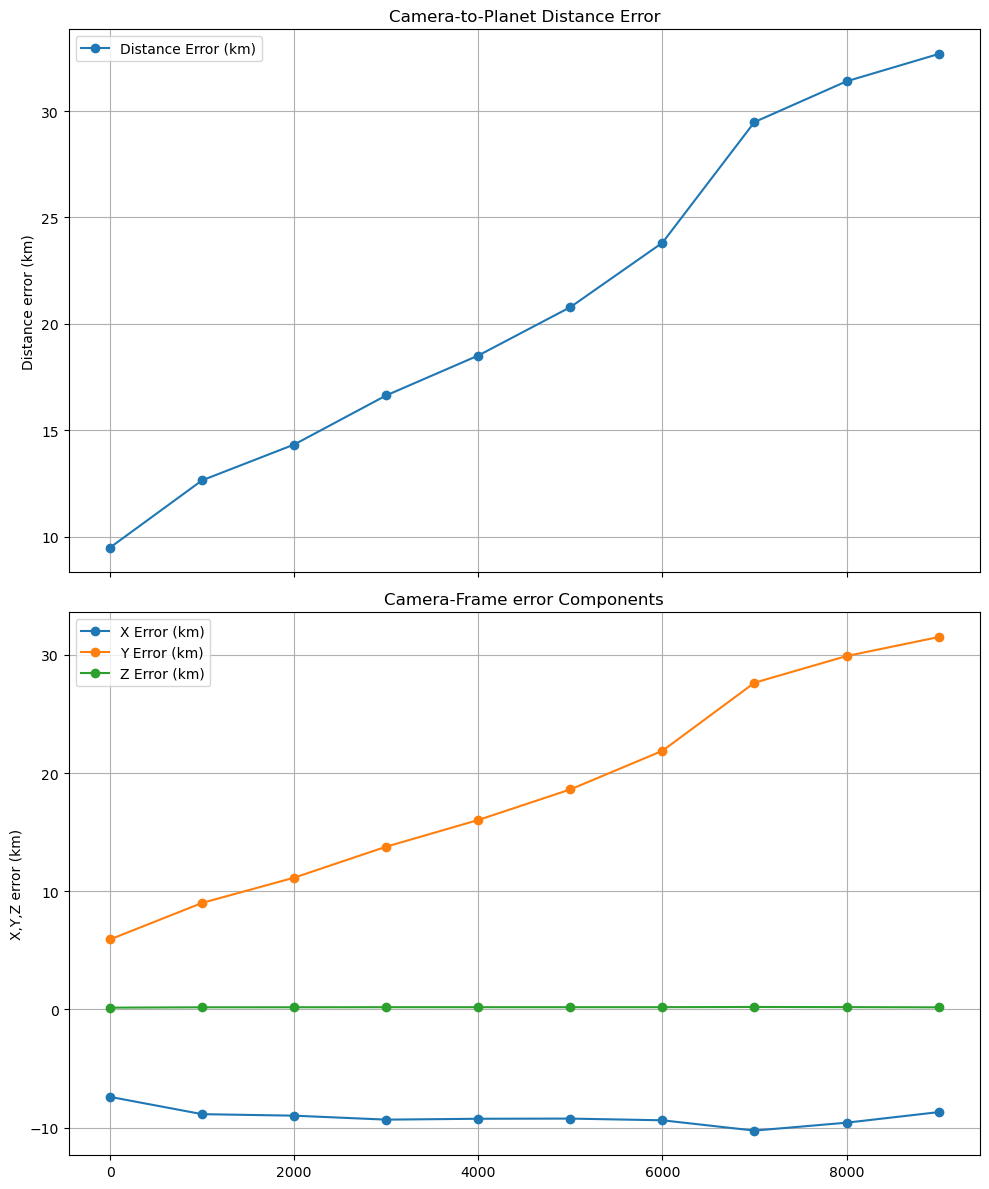

In [129]:
plot_est_dist_xyz_errors(
    times,
    pos,
    estimates,
)

In [130]:
# EKF time
Q = np.diag([1,1, 1, 0.0001, 0.0001, 0.0001])  # Process noise covariance

Q_perfect = np.zeros((6, 6))  # Perfect process model (no noise)

R_1 = 1000


R = np.diag([R_1, R_1, R_1])  # Measurement noise covariance
dt = 1000.0  # Time step in seconds
t = 0 
N = 50

state_0 = np.array(State0)
mu0 = state_0
sigma0 = np.diag([1.0, 1.0, 1.0,  0.0001, 0.0001, 0.0001])  # Initial state covariance

central_body_mass = 7.34767309e22

ekf = SatEKF(Q, R, dt, mu0, sigma0, central_body_mass)



[-5.000e+03  4.000e+03  1.000e+02  0.000e+00  1.075e+00  0.000e+00]


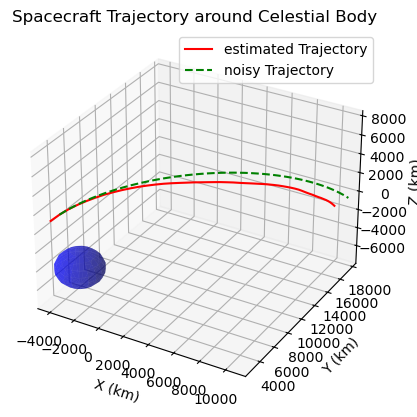

In [131]:
state = np.array(state_0)
print(state)
states_noisy = [state]
states_perfect = []
state_clean = state

# get noisy trajectory for EKF testing
for i in range(N):
    process_noise = np.random.multivariate_normal(np.zeros(6), Q)
    state_next_perfect= ekf.f_func(state_clean) 
    state_next_noisy = ekf.f_func(state) + process_noise
    t += dt
    states_perfect.append(state_next_perfect)
    states_noisy.append(state_next_noisy)
    state = state_next_noisy
    state_clean = state_next_perfect

states_noisy = np.array(states_noisy)
states_perfect = np.array(states_perfect)

ts = np.arange(0, N*dt, dt)

plot_trajs(states_noisy, states_perfect, body_struct)

In [132]:
# get CR estimates for EKF measurement updates
print(ts[i])
print(states_noisy[i])
cam_offset = np.array([0, 0, 0]) # no offset for now
images, edges, outs, states, times = get_images(states_noisy, ts, body_struct, cam_offset, camera_spec_ellie, N)


49000.0
[ 1.131e+04  1.476e+04  9.603e+02  2.145e-01 -1.928e-01  6.979e-02]
State at t=0.0s: [-5.000e+03  4.000e+03  1.000e+02  0.000e+00  1.075e+00  0.000e+00]
State at t=1000.0s: [-4.953e+03  5.039e+03  9.778e+01  8.121e-02  9.868e-01 -2.160e-02]
State at t=2000.0s: [-4.838e+03  5.992e+03  7.423e+01  1.523e-01  9.057e-01 -3.357e-02]
State at t=3000.0s: [-4.660e+03  6.865e+03  4.032e+01  2.002e-01  8.319e-01 -3.708e-02]
State at t=4000.0s: [-4.440e+03  7.666e+03  2.325e+00  2.390e-01  7.882e-01 -4.365e-02]
State at t=5000.0s: [-4.184e+03  8.428e+03 -3.941e+01  2.771e-01  7.285e-01 -3.309e-02]
State at t=6000.0s: [-3.895e+03  9.131e+03 -7.089e+01  3.141e-01  6.997e-01 -5.067e-02]
State at t=7000.0s: [-3.572e+03  9.810e+03 -1.217e+02  3.348e-01  6.460e-01 -4.614e-02]
State at t=8000.0s: [-3.229e+03  1.043e+04 -1.659e+02  3.716e-01  5.904e-01 -3.161e-02]
State at t=9000.0s: [-2.851e+03  1.101e+04 -1.981e+02  3.747e-01  5.605e-01 -3.883e-02]
State at t=10000.0s: [-2.473e+03  1.155e+04 -2.

In [133]:
estimates = []
tpcs = []
for i in range(len(outs)):
    print(f"Running CR alg on image {i+1}/{len(outs)}")
    out = outs[i]
    state = states[i]
    edge = edges[i]
    
    # Compute planet-to-camera rotation matrix from render output
    tpc = get_tpc(out)
    tpcs.append(tpc)
    
    # Prepare edge points as homogeneous coordinates [x, y, 1]
    edge_homogeneous = np.hstack((edge, np.ones((edge.shape[0], 1))))

    # Run Christian-Robinson: estimates camera->planet vector in camera frame
    rc_est, rp_est = run_step(edge_homogeneous, state[0:3], tpc, print_stats=True, cr_alg=cr_alg)
    estimates.append(rp_est)

Running CR alg on image 1/50
Calc Position:
 - (C->P in camera frame): [   0.     -0.   6413.39] (6413.39 km)
 - (C->P in planet frame): [ 5007.4  -4005.92  -100.15] (6413.39 km)
Actual position:
 - (C->P in camera frame): [   0.     -0.   6403.91] (6403.91 km)
 - (C->P in planet frame): [ 5000. -4000.  -100.] (6403.91 km)
Est Error - Actual:
 - (Camera frame): [ 0.   -0.    9.48] (9.48 km)
 - (Planet frame): [ 7.4  -5.92 -0.15] (9.48 km)
Distance error: 9.48 km (0.148060%)
Angular error: 0.0000 degrees
Running CR alg on image 2/50
Calc Position:
 - (C->P in camera frame): [  -0.     -0.   7078.64] (7078.64 km)
 - (C->P in planet frame): [ 4961.67 -5047.71   -97.94] (7078.64 km)
Actual position:
 - (C->P in camera frame): [  -0.      0.   7066.94] (7066.94 km)
 - (C->P in planet frame): [ 4953.47 -5039.37   -97.78] (7066.94 km)
Est Error - Actual:
 - (Camera frame): [-0.  -0.  11.7] (11.70 km)
 - (Planet frame): [ 8.2  -8.34 -0.16] (11.70 km)
Distance error: 11.70 km (0.165575%)
Angula

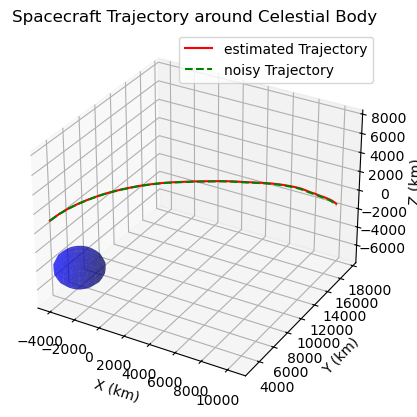

In [135]:
estimates = np.array(estimates)

plot_trajs(-estimates, states_noisy, body_struct)

In [136]:
# now its kalman filtering time
tpcs = np.array(tpcs)
mus = [mu0]
sigmas = [sigma0]
for i in range(N):
    print(f"EKF step {i+1}/{N}")
    ekf.predict()
    print("meauments", estimates[i])
    print("Predicted state:", ekf.mu)
    ekf.update(estimates[i],tpcs[i])
    mus.append(ekf.mu)
    sigmas.append(ekf.sigma)


print("Final EKF state estimate:", ekf.mu)

EKF step 1/50
meauments [ 5007.403 -4005.922  -100.148]
Predicted state: [-4.953e+03  5.038e+03  9.907e+01  9.336e-02  1.000e+00 -1.867e-03]
Measurement function output: [-1.421e-14 -8.395e+02 -7.016e+03]
EKF step 2/50
meauments [ 4961.672 -5047.712   -97.944]
Predicted state: [-3.451e+03  5.655e+03  9.828e+02  8.484e-01  7.453e-01  4.291e-01]
Measurement function output: [  914.467 -1490.693 -6465.338]
EKF step 3/50
meauments [ 4846.506 -6002.661   -74.366]
Predicted state: [1.042e+03 5.243e+03 3.353e+03 2.253e+00 1.854e-01 1.105e+00]
Measurement function output: [ 3368.445 -4064.616 -3457.018]
EKF step 4/50
meauments [ 4669.146 -6878.472   -40.403]
Predicted state: [ 5.831e+03  4.345e+03  5.386e+03  2.999e+00 -2.278e-01  1.328e+00]
Measurement function output: [ 5435.886 -7226.008  -346.01 ]
EKF step 5/50
meauments [ 4.450e+03 -7.683e+03 -2.330e+00]
Predicted state: [ 8.714e+03  3.744e+03  6.113e+03  2.926e+00 -3.647e-01  1.123e+00]
Measurement function output: [ 6118.007 -9414.893  

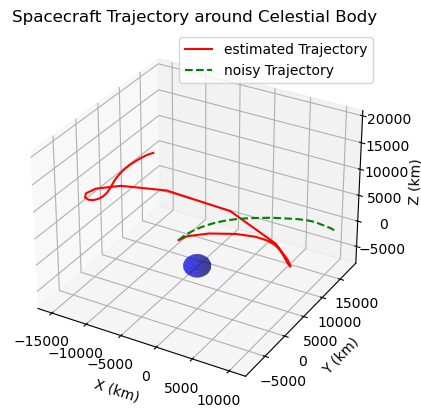

In [137]:
mus = np.array(mus)
sigmas = np.array(sigmas)
plot_trajs(mus, states_noisy, body_struct)


Final EKF state estimate: [-1.209e+04  9.824e+03  1.037e+04  2.763e-01  1.340e-01  1.515e-01]


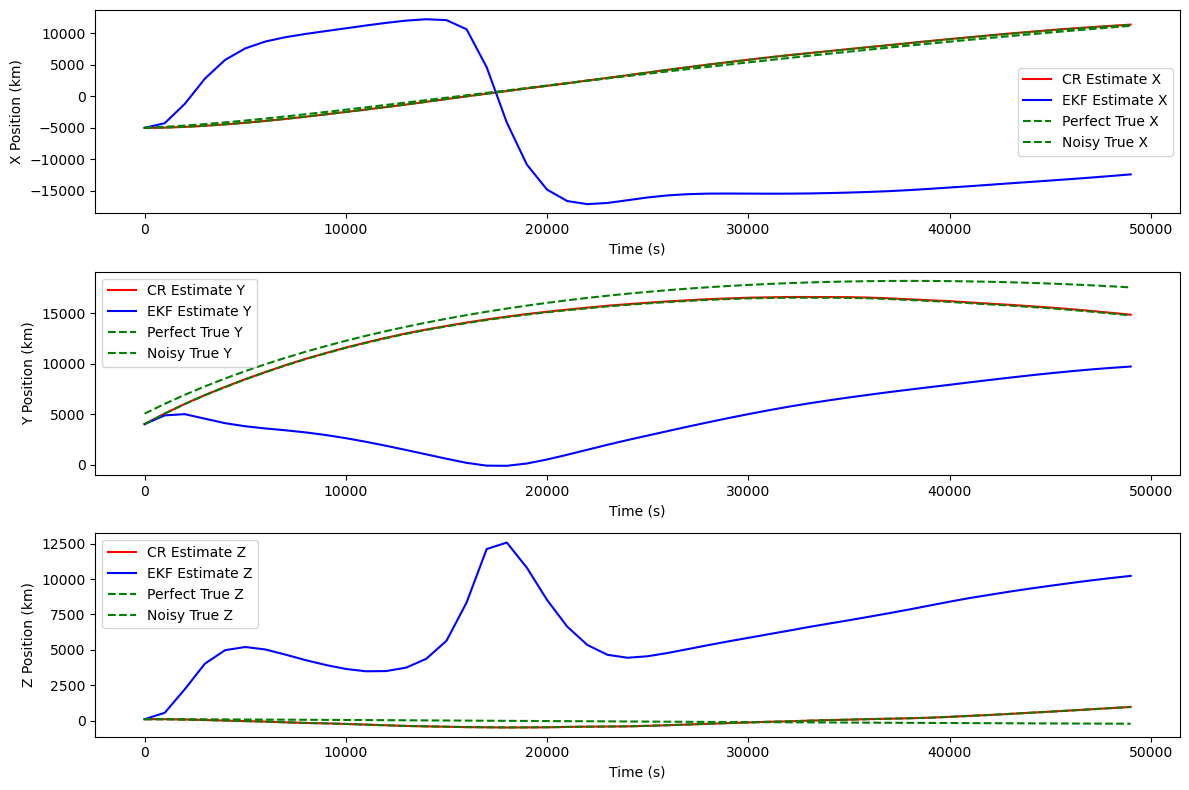

In [138]:
# plot EKF estimates vs true trajectory and CR estimates vs time
mus = np.array(mus)
estimates= np.array(estimates)
states_noisy = np.array(states_noisy)
    

plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
print("Final EKF state estimate:", ekf.mu)
plt.plot(ts, -estimates[:, 0], label='CR Estimate X', color='r')
# Align array lengths with ts (mus and states_noisy are length 51, ts is 50)
mus = mus[:len(ts)]
states_noisy = states_noisy[:len(ts)]
plt.plot(ts, mus[:, 0], label='EKF Estimate X', color='b')
plt.plot(ts, states_perfect[:, 0], label='Perfect True X', color='g', linestyle='--')
plt.plot(ts, states_noisy[:, 0], label='Noisy True X', color='g', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('X Position (km)')
plt.legend()
plt.subplot(3, 1, 2)
plt.plot(ts, -estimates[:, 1], label='CR Estimate Y', color='r')
plt.plot(ts, mus[:, 1], label='EKF Estimate Y', color='b')
plt.plot(ts, states_perfect[:, 1], label='Perfect True Y', color='g', linestyle='--')
plt.plot(ts, states_noisy[:, 1], label='Noisy True Y', color='g', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Y Position (km)')
plt.legend()
plt.subplot(3, 1, 3)
plt.plot(ts, -estimates[:, 2], label='CR Estimate Z', color='r')
plt.plot(ts, mus[:, 2], label='EKF Estimate Z', color='b')
plt.plot(ts, states_perfect[:, 2], label='Perfect True Z', color='g', linestyle='--')
plt.plot(ts, states_noisy[:, 2], label='Noisy True Z', color='g', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Z Position (km)')
plt.legend()
plt.tight_layout()
plt.show()